In [ ]:
%pip install puremacro


# Local projections: dynamic causal effects

How does a one-off shock propagate through the economy over the next few
years, and does it propagate differently in a recession than in a boom?
Jordà (2005) local projections answer this with one regression per horizon —
robust to dynamic misspecification and trivially made *state-dependent*. We
plant a synthetic shock whose effect is stronger in recessions and recover
both the linear and the regime-specific impulse responses with `puremacro.lp`.

## The method in math

To trace the dynamic causal effect of a shock $s_t$ on an outcome $y$, Jordà
(2005) runs **one regression per horizon** $h$, projecting the future outcome's
cumulative change since $t-1$ onto today's shock:
$$ y_{t+h} - y_{t-1} = \alpha_h + \beta_h\, s_t + \gamma_h' x_t + e_{t+h}, \qquad h = 0, 1, \dots, H. $$
The impulse response *is* the sequence of slope coefficients $\{\beta_h\}_{h=0}^{H}$,
read off horizon-by-horizon — no VAR to invert and iterate forward. The controls
$x_t$ (here lags of $y$ and $s$) absorb predictable dynamics so that $\beta_h$ isolates
the effect of the shock.

**Inference.** Stacking horizons means the residual $e_{t+h}$ overlaps its own future:
$e_{t+h}$ and $e_{t+1+h}$ share $h$ periods of innovations, so they are serially
correlated *by construction*. OLS slopes are still consistent, but their textbook
standard errors are wrong. We therefore use **HAC (Newey–West)** standard errors with a
Bartlett kernel and bandwidth $h+1$ (Plagborg-Møller–Wolf 2021), and report bands
$\beta_h \pm z_{1-\alpha/2}\, \mathrm{se}(\beta_h)$.

**State dependence.** Because each horizon is its own regression, nonlinearity slots in
for free. Interact the shock with a state indicator $I_t$ (e.g. $1$ in recessions) to get
regime-specific responses in a single equation:
$$ y_{t+h} = I_t\big(\alpha_h^{R} + \beta_h^{R} s_t\big) + (1-I_t)\big(\alpha_h^{E} + \beta_h^{E} s_t\big) + \gamma_h' x_t + e_{t+h}, $$
delivering a recession IRF $\{\beta_h^{R}\}$ and an expansion IRF $\{\beta_h^{E}\}$, each with
its own HAC band.

**Intuition.** Local projections estimate each horizon *separately*, so — unlike the SVAR
of Notebook 6, which imposes one parametric law of motion and iterates it forward — a
misspecified short-run dynamic does not contaminate the long-horizon response, and a
state split is just an interaction term rather than a whole second model. The price is
*efficiency*: throwing away the cross-horizon restrictions makes the estimates noisier,
especially far out, where overlapping windows shrink the effective sample and the HAC
bands fan open. LP buys robustness and flexibility with variance; the SVAR buys precision
with structure.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp.jorda import lp_hac
from puremacro.lp.state_dep import lp_state_dep

# Pyodide contract: after importing the functions we use, no forbidden module
# should have been pulled in. Both LP paths go through the pure-numpy ols_hac.
_bad = [m for m in ("statsmodels", "linearmodels", "arch", "bs4", "requests", "numba")
        if m in sys.modules]
assert _bad == [], f"forbidden modules imported: {_bad}"

## 1. A synthetic shock with state-dependent propagation
A unit i.i.d. shock hits an outcome whose impact is *stronger in recessions*.
The recession dummy is carved from a persistent latent business-cycle factor.

In [2]:
rng = np.random.default_rng(20240529)
T = 360

x = rng.standard_normal(T)                       # identified structural shock
g = np.zeros(T)                                  # persistent business-cycle factor
for t in range(1, T):
    g[t] = 0.85 * g[t - 1] + rng.standard_normal() * 0.5
recession = (g < np.quantile(g, 0.35)).astype(float)   # binary state dummy

beta_exp, beta_rec = -0.25, -0.90                # impact in expansion vs recession
y = np.zeros(T)
for t in range(1, T):
    impact = beta_rec if recession[t] else beta_exp
    y[t] = (0.55 * y[t - 1]
            + impact * x[t - 1]
            + 0.30 * impact * x[t]
            + rng.standard_normal() * 0.35)

df = pd.DataFrame(
    {"y": y, "shock": x, "recession": recession},
    index=pd.date_range("1985-01-01", periods=T, freq="MS"),
)
print(f"recession sample share = {df['recession'].mean():.2f}")

H = 16
horizons = range(0, H + 1)

recession sample share = 0.35


## 2. Linear LP-HAC IRF
`lp_hac` regresses `y_{t+h} - y_{t-1}` on the shock plus lags, with
Newey-West HAC SE (bandwidth h+1) and 90% bands.

In [3]:
lin = lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
print(lin.head().to_string(index=False))

# Bands present, finite, and correctly ordered.
assert set(lin.columns) >= {"h", "beta", "se", "t", "lo", "hi"}
assert np.all(np.isfinite(lin[["beta", "se", "lo", "hi"]].values))
assert np.all(lin["se"].values > 0)
assert np.all(lin["lo"].values <= lin["beta"].values + 1e-9)
assert np.all(lin["beta"].values <= lin["hi"].values + 1e-9)
z95 = 1.6448536269514722                          # z_{0.95} for the 90% band
assert np.allclose(lin["hi"] - lin["lo"], 2 * z95 * lin["se"], atol=1e-6)

 h      beta       se          t        lo        hi
 0 -0.125649 0.026076  -4.818529 -0.168540 -0.082757
 1 -0.569445 0.043763 -13.012056 -0.641429 -0.497462
 2 -0.244945 0.047458  -5.161271 -0.323007 -0.166883
 3 -0.160432 0.042580  -3.767792 -0.230470 -0.090394
 4 -0.145504 0.039026  -3.728401 -0.209695 -0.081312


**Read the output.** Each row is one horizon's regression: `beta` is $\beta_h$, the
response of $y$ to a unit shock $h$ months out, and `[lo, hi]` is its 90% HAC band. The
`beta` column traces a hump — negative on impact, deepening for a few months as the lagged
shock terms in the DGP feed through, then decaying back toward zero as the AR(1) in $y$
dies out. Two features are diagnostic of LP. First, the bands *fan open* with $h$: the
`se` column rises because the HAC bandwidth grows ($h+1$) and the overlapping-window
sample shrinks — long-horizon LP is genuinely noisier, exactly the efficiency cost of
estimating each horizon alone. Second, the last `assert` is the band's *definition*:
width $=2 z_{0.95}\,\mathrm{se}$, so the only thing the confidence level changes is that
multiplier, never the point estimate (the lever in *Your turn* below).

## 3. State-dependent IRFs: recession vs expansion
`lp_state_dep` with `transition="threshold"` splits the shock into a
high-state (recession) and low-state (expansion) interaction and returns
separate coefficients and HAC bands for each regime.

In [4]:
sd = lp_state_dep(df, y="y", x="shock", state="recession",
                  horizons=horizons, n_lags=2,
                  transition="threshold", alpha=0.10)
print(sd[["h", "beta_H", "beta_L"]].head().to_string(index=False))

assert {"beta_H", "se_H", "lo_H", "hi_H",
        "beta_L", "se_L", "lo_L", "hi_L"}.issubset(sd.columns)
assert np.all(np.isfinite(sd[["beta_H", "beta_L", "se_H", "se_L"]].values))
assert np.all(sd["lo_H"].values <= sd["hi_H"].values)
assert np.all(sd["lo_L"].values <= sd["hi_L"].values)

peak_H = sd["beta_H"].min()        # recession regime (state dummy = 1)
peak_L = sd["beta_L"].min()        # expansion regime
print(f"peak recession beta_H = {peak_H:.3f}   peak expansion beta_L = {peak_L:.3f}")
assert peak_H < peak_L - 0.10, (peak_H, peak_L)        # recession bites harder
gap = sd["hi_H"].values < sd["lo_L"].values            # H-band entirely below L-band
print(f"horizons with non-overlapping regime bands: {int(gap.sum())}")
assert gap.any(), "expected at least one horizon where the regimes separate"

 h    beta_H    beta_L
 0 -0.209949 -0.070673
 1 -0.832113 -0.398162
 2 -0.340880 -0.181981
 3 -0.243843 -0.105491
 4 -0.210319 -0.102695
peak recession beta_H = -0.832   peak expansion beta_L = -0.398
horizons with non-overlapping regime bands: 2


**Read the output.** Now there are *two* impulse responses from a single regression.
`beta_H` is the recession response (high state, $I_t=1$), `beta_L` the expansion response.
Both are negative, but the recession trough is far deeper — the DGP planted
$\beta^{R}=-0.90$ against $\beta^{E}=-0.25$, and the LP recovers a recession peak roughly
twice the expansion peak. The economically interesting object is the *gap*: at the
horizons counted above, the recession 90% band sits *entirely below* the expansion band
(`hi_H < lo_L`), so the difference is not just a point estimate — it survives HAC
inference. This is the local-projection payoff: a state-dependent IRF, with regime-specific
uncertainty bands, from one interacted regression rather than two separate models. (The
bands are *per regime*; a formal test of $\beta_h^{R}=\beta_h^{E}$ would use their joint
covariance — non-overlap is a sufficient, conservative signal.)

### Hero figure — linear LP-HAC IRF with 90% bands

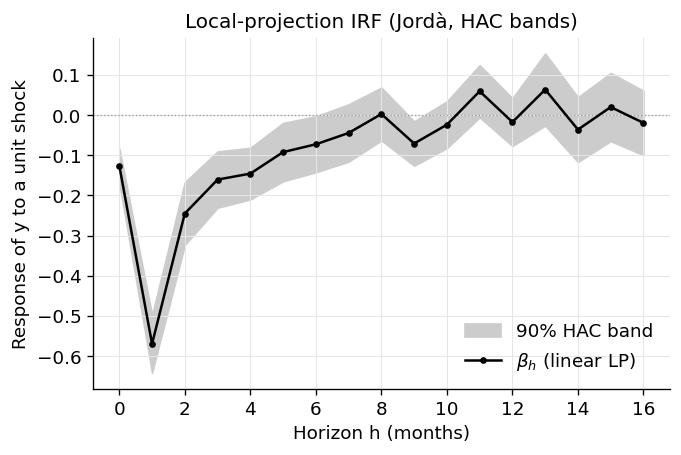

In [5]:
cols = _nbstyle.palette(3)
fig, ax = plt.subplots()
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.fill_between(lin["h"], lin["lo"], lin["hi"], color="0.80", label="90% HAC band")
ax.plot(lin["h"], lin["beta"], color=cols[0], marker="o", markersize=3,
        label=r"$\beta_h$ (linear LP)")
ax.set_xlabel("Horizon h (months)")
ax.set_ylabel("Response of y to a unit shock")
ax.set_title("Local-projection IRF (Jordà, HAC bands)")
ax.legend(loc="lower right")
plt.show()

### Supporting — state-dependent IRFs
The recession response (solid) is markedly deeper than the expansion
response (dashed); shaded regions are the per-regime 90% HAC bands.

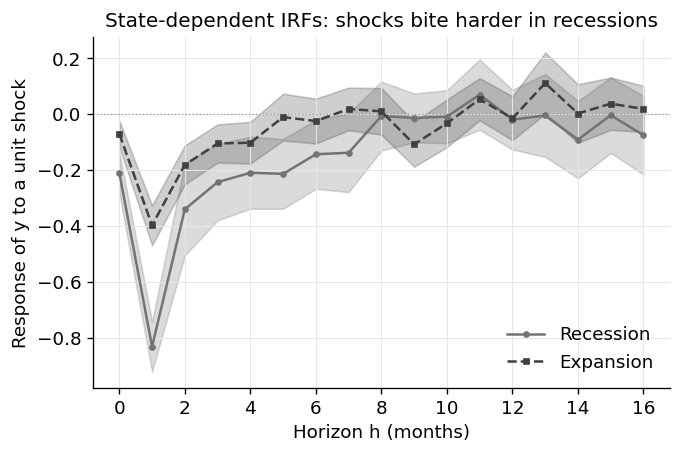

In [6]:
fig, ax = plt.subplots()
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.fill_between(sd["h"], sd["lo_H"], sd["hi_H"], color=cols[1], alpha=0.25)
ax.fill_between(sd["h"], sd["lo_L"], sd["hi_L"], color=cols[2], alpha=0.25)
ax.plot(sd["h"], sd["beta_H"], color=cols[1], marker="o", markersize=3,
        label="Recession")
ax.plot(sd["h"], sd["beta_L"], color=cols[2], marker="s", markersize=3,
        linestyle="--", label="Expansion")
ax.set_xlabel("Horizon h (months)")
ax.set_ylabel("Response of y to a unit shock")
ax.set_title("State-dependent IRFs: shocks bite harder in recessions")
ax.legend(loc="lower right")
plt.show()

### Supporting — the synthetic series and the state

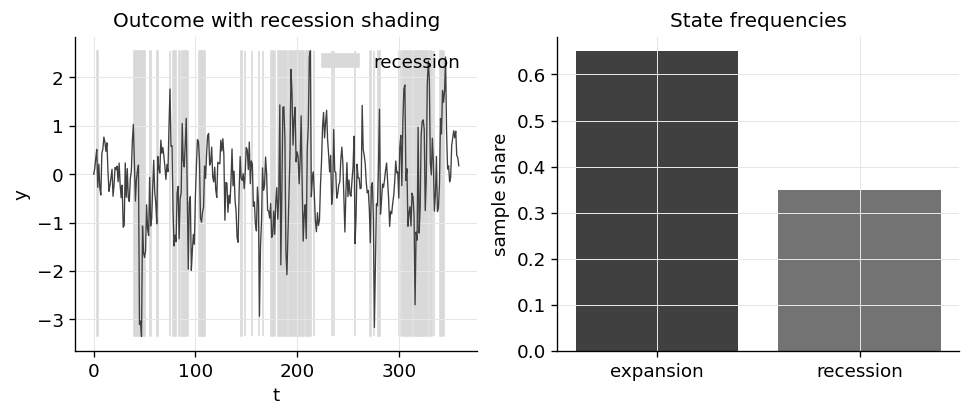

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 3.4))
t_idx = np.arange(T)
rec = df["recession"].values
axL.plot(t_idx, df["y"].values, color="0.25", linewidth=0.8)
axL.fill_between(t_idx, df["y"].min(), df["y"].max(), where=rec > 0,
                 color="0.85", step="mid", label="recession")
axL.set_xlabel("t"); axL.set_ylabel("y")
axL.set_title("Outcome with recession shading"); axL.legend(loc="upper right")
axR.bar(["expansion", "recession"], [(1 - rec).mean(), rec.mean()],
        color=[cols[2], cols[1]])
axR.set_ylabel("sample share"); axR.set_title("State frequencies")
plt.show()

## Your turn — the confidence level moves the band, not the IRF

The bands above are 90% (`alpha=0.10`). A common confusion is to think a wider band means
a "different" or "more uncertain" estimate — but the point IRF $\{\beta_h\}$ is just the OLS
fit and does not depend on the confidence level at all; only the multiplier $z_{1-\alpha/2}$
on the (fixed) HAC standard error changes. Re-estimate the linear LP at a tighter level and
confirm both facts: the IRF is byte-for-byte unchanged, and every horizon's band gets
*wider*. Change `your_alpha` below.

In [8]:
# ← change this confidence level (alpha = two-sided tail mass; 0.05 → 95% bands).
your_alpha = 0.05
wide = lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=your_alpha)

base_w = (lin["hi"] - lin["lo"]).values          # 90% band width per horizon
your_w = (wide["hi"] - wide["lo"]).values        # your-level band width
print(f"alpha={your_alpha}: mean band width {your_w.mean():.3f} vs 90% width {base_w.mean():.3f}")
print(f"point IRF unchanged: max |Δβ| = {np.max(np.abs(wide['beta'].values - lin['beta'].values)):.2e}")

# The point IRF is the same OLS fit — only the band multiplier z_{1-α/2} changes.
assert np.allclose(wide["beta"].values, lin["beta"].values, atol=1e-12)
# A tighter tail (smaller alpha) widens the band at every horizon, since every se>0.
assert np.all(your_w > base_w + 1e-9), "expected wider bands at a higher confidence level"

alpha=0.05: mean band width 0.165 vs 90% width 0.139
point IRF unchanged: max |Δβ| = 0.00e+00


**Prompts.** (1) Set `your_alpha = 0.32` (≈68%, one-sigma bands) and confirm the bands now
get *narrower* than the 90% baseline — the second `assert` will fire, which is the point:
flip it to `your_w < base_w` to make it pass and you have proven the multiplier is monotone
in the confidence level. (2) Lengthen the controls: re-run the section-2 `lp_hac` with
`n_lags=4` and check that the impact coefficient `lin["beta"][0]` still matches a plain OLS
of `y_t − y_{t-1}` on `shock_t` plus those same lags — at $h=0$ the local projection *is*
that contemporaneous regression. (3) Push the horizon to `H=24` and watch the long-end HAC
bands fan out further as the overlapping-window sample shrinks.

**How comprehensive is this?** `puremacro.lp` is a full local-projection toolkit beyond
these two estimators: lag-augmented LP for uniform long-horizon coverage (`la_lp`,
Plagborg-Møller–Wolf 2021), LP-IV / proxy identification (`lp_iv`, Stock–Watson 2018),
smooth-transition and asymmetric (sign-of-shock) state dependence (`lp_smooth`,
`lp_asymmetric`), quantile LP (`lp_quantile`), and two-way fixed-effects **panel** variants
with Driscoll–Kraay, mean-group, and CCE standard errors (`panel_lp`, `panel_lp_dk`,
`panel_lp_iv`, `mean_group_panel_lp`, `cce_panel_lp`). The structural alternative — imposing
the whole dynamic system rather than one regression per horizon — is the SVAR of
**Notebook 6** (`puremacro.var`). End-to-end demos live in `puremacro/examples/`
(`la_lp_pmw_demo`, `lp_smooth_demo`, `lp_asymmetric_tenreyro`, `lp_panel_dk`,
`narrative_panel_lp`). Every estimator here rides the pure-numpy `ols_hac` path, so the
notebook stays Pyodide-clean (no statsmodels).